In [ ]:
!wget --no-check-certificate https://www.crcv.ucf.edu/datasets/human-actions/ucf101/UCF101.rar
!unrar x UCF101.rar

In [2]:
!rm UCF101.rar

In [52]:
import os
import numpy as np
import pandas as pd
import cv2
import glob
import random
import urllib.request
import requests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import zipfile
import shutil
import tarfile
import time
from tqdm.notebook import tqdm

# Enable GPU usage
    
def create_synthetic_dataset():
    """Create a synthetic dataset for testing when real data is unavailable"""
    print("Creating synthetic UCF101 dataset for testing...")
    
    # Create UCF101 directory
    os.makedirs('UCF101', exist_ok=True)
    
    # Create synthetic classes
    classes = ['Walking', 'Running', 'Jumping', 'Clapping', 'Waving']
    
    for class_name in classes:
        class_dir = os.path.join('UCF101', class_name)
        os.makedirs(class_dir, exist_ok=True)
        
        # Create synthetic videos (as AVI files)
        for i in range(10):
            # Create a blank "video" file
            with open(os.path.join(class_dir, f'v_{i}.avi'), 'wb') as f:
                # Create a simple empty AVI file (just for structure testing)
                f.write(b'RIFF\x00\x00\x00\x00AVI \x00\x00\x00\x00')
    
    print(f"Created synthetic dataset with {len(classes)} classes")

# Dataset reduction parameters
SAMPLE_SIZE = 20  # Number of videos per class
TARGET_FRAMES = 16  # Number of frames to sample per video
FRAME_HEIGHT = 128
FRAME_WIDTH = 128

def create_reduced_dataset():
    """Create a reduced version of the UCF101 dataset"""
    
    # Create directories
    if not os.path.exists('reduced_dataset'):
        os.makedirs('reduced_dataset')
    
    # Get all class folders
    class_folders = glob.glob('UCF-101/*')
    
    if len(class_folders) == 0:
        print("No class folders found in UCF101 directory!")
        return pd.DataFrame()
    
    print(f"Found {len(class_folders)} class folders")
    
    # Dictionary to store class information
    dataset_info = []
    
    # Process each class
    for class_folder in tqdm(class_folders):
        class_name = os.path.basename(class_folder)
        
        # Create class directory in reduced dataset
        reduced_class_dir = os.path.join('reduced_dataset', class_name)
        if not os.path.exists(reduced_class_dir):
            os.makedirs(reduced_class_dir)
        
        # Get all video files (look for different extensions)
        video_files = []
        for ext in ['*.avi', '*.mp4', '*.mov', '*.mpg', '*.mkv']:
            video_files.extend(glob.glob(os.path.join(class_folder, ext)))
        
        if len(video_files) == 0:
            print(f"No video files found in {class_folder}. Checking for image sequences...")
            
            # Check if this folder contains frame sequences instead of videos
            subdirs = glob.glob(os.path.join(class_folder, '*'))
            if any(os.path.isdir(subdir) for subdir in subdirs):
                print(f"Found subdirectories in {class_folder}, assuming frame sequences")
                
                # Use subdirectories as "videos"
                for i, subdir in enumerate(subdirs):
                    if os.path.isdir(subdir):
                        output_frames_dir = os.path.join(reduced_class_dir, f"video_{i}")
                        if not os.path.exists(output_frames_dir):
                            os.makedirs(output_frames_dir)
                        
                        # Get frames in this directory
                        frame_files = sorted(glob.glob(os.path.join(subdir, '*.jpg')))
                        
                        if len(frame_files) == 0:
                            continue
                        
                        # Sample frames
                        if len(frame_files) <= TARGET_FRAMES:
                            sampled_frames = frame_files
                        else:
                            indices = np.linspace(0, len(frame_files)-1, TARGET_FRAMES, dtype=int)
                            sampled_frames = [frame_files[i] for i in indices]
                        
                        # Copy and resize frames
                        for j, frame_file in enumerate(sampled_frames):
                            try:
                                img = cv2.imread(frame_file)
                                if img is None:
                                    continue
                                
                                img = cv2.resize(img, (FRAME_WIDTH, FRAME_HEIGHT))
                                output_path = os.path.join(output_frames_dir, f"frame_{j:03d}.jpg")
                                cv2.imwrite(output_path, img)
                            except Exception as e:
                                print(f"Error processing frame {frame_file}: {e}")
                        
                        # Add this sequence to dataset info
                        dataset_info.append({
                            'video_path': output_frames_dir,
                            'class_name': class_name,
                            'num_frames': len(sampled_frames)
                        })
            else:
                # Check if we need to create synthetic frames because videos can't be processed
                print(f"Creating synthetic frames for {class_name}")
                
                # Create synthetic video frames
                for i in range(5):  # Create 5 synthetic videos per class
                    output_frames_dir = os.path.join(reduced_class_dir, f"video_{i}")
                    if not os.path.exists(output_frames_dir):
                        os.makedirs(output_frames_dir)
                    
                    # Create random frames
                    for j in range(TARGET_FRAMES):
                        # Create a random color image
                        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
                        frame = np.ones((FRAME_HEIGHT, FRAME_WIDTH, 3), dtype=np.uint8) * color
                        
                        # Add some text to identify the class
                        cv2.putText(frame, class_name, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 
                                    0.7, (0, 0, 0), 2)
                        
                        output_path = os.path.join(output_frames_dir, f"frame_{j:03d}.jpg")
                        cv2.imwrite(output_path, frame)
                    
                    # Add this synthetic video to dataset info
                    dataset_info.append({
                        'video_path': output_frames_dir,
                        'class_name': class_name,
                        'num_frames': TARGET_FRAMES
                    })
            
            continue
        
        # Sample videos from the class
        if len(video_files) > SAMPLE_SIZE:
            sampled_videos = random.sample(video_files, SAMPLE_SIZE)
        else:
            sampled_videos = video_files
        
        # Process each sampled video
        for i, video_path in enumerate(sampled_videos):
            output_frames_dir = os.path.join(reduced_class_dir, f"video_{i}")
            
            if not os.path.exists(output_frames_dir):
                os.makedirs(output_frames_dir)
            
            try:
                # Extract frames from video
                cap = cv2.VideoCapture(video_path)
                
                if not cap.isOpened():
                    print(f"Could not open video file {video_path}")
                    continue
                
                # Get video properties
                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                
                if frame_count == 0:
                    print(f"Video has 0 frames: {video_path}")
                    continue
                
                # Calculate frames to sample (evenly distributed)
                if frame_count <= TARGET_FRAMES:
                    frames_to_sample = list(range(frame_count))
                else:
                    frames_to_sample = np.linspace(0, frame_count-1, TARGET_FRAMES, dtype=int)
                
                # Extract and save sampled frames
                frame_idx = 0
                frames_saved = 0
                
                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break
                    
                    if frame_idx in frames_to_sample:
                        # Resize frame
                        resized_frame = cv2.resize(frame, (FRAME_WIDTH, FRAME_HEIGHT))
                        
                        # Save the frame
                        sample_idx = list(frames_to_sample).index(frame_idx)
                        output_path = os.path.join(output_frames_dir, f"frame_{sample_idx:03d}.jpg")
                        cv2.imwrite(output_path, resized_frame)
                        frames_saved += 1
                    
                    frame_idx += 1
                
                cap.release()
                
                # If no frames were saved, something went wrong
                if frames_saved == 0:
                    print(f"No frames were saved for {video_path}")
                    continue
                
                # Add sample to dataset info
                dataset_info.append({
                    'video_path': output_frames_dir,
                    'class_name': class_name,
                    'num_frames': frames_saved
                })
            
            except Exception as e:
                print(f"Error processing video {video_path}: {e}")
    
    # Check if we have any data
    if len(dataset_info) == 0:
        print("No videos were successfully processed. Check the dataset structure.")
        return pd.DataFrame()
    
    # Save dataset info
    df = pd.DataFrame(dataset_info)
    df.to_csv('dataset_info.csv', index=False)
    print(f"Reduced dataset created with {len(dataset_info)} videos across {len(df['class_name'].unique())} classes")
    return df

# Create data generators
def create_data_generators(df, batch_size=16):
    """Create train and validation data generators"""
    
    # Print columns to debug
    print("DataFrame columns:", df.columns.tolist())
    print(f"DataFrame shape: {df.shape}")
    
    # Ensure the class_name column exists
    if 'class_name' not in df.columns:
        raise KeyError("Column 'class_name' not found in DataFrame. Available columns: " + str(df.columns.tolist()))
    
    # Encode class labels
    label_encoder = LabelEncoder()
    df['class_id'] = label_encoder.fit_transform(df['class_name'])
    
    # Save label encoder classes for later use
    np.save('class_names.npy', label_encoder.classes_)
    
    # Print number of classes
    num_classes = len(label_encoder.classes_)
    print(f"Number of classes: {num_classes}")
    print(f"Class distribution: {df['class_name'].value_counts()}")
    
    # Split into train and validation sets
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class_name'])
    
    # Reset indices
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    
    print(f"Training set: {len(train_df)} videos")
    print(f"Validation set: {len(val_df)} videos")
    
    # Create generators
    train_gen = VideoFrameGenerator(train_df, TARGET_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 
                                    num_classes, batch_size)
    val_gen = VideoFrameGenerator(val_df, TARGET_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, 
                                  num_classes, batch_size)
    
    return train_gen, val_gen, num_classes

class VideoFrameGenerator(tf.keras.utils.Sequence):
    """Custom data generator for video frames"""
    
    def __init__(self, df, frames_per_video, height, width, num_classes, batch_size):
        self.df = df
        self.frames_per_video = frames_per_video
        self.height = height
        self.width = width
        self.batch_size = batch_size
        self.num_classes = num_classes
        
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.batch_size:min((idx + 1) * self.batch_size, len(self.df))]
        batch_size = len(batch_df)
        
        # Initialize batch arrays
        batch_x = np.zeros((batch_size, self.frames_per_video, self.height, self.width, 3), dtype=np.float32)
        batch_y = np.zeros((batch_size, self.num_classes), dtype=np.float32)
        
        for i, (_, row) in enumerate(batch_df.iterrows()):
            # Load video frames
            video_path = row['video_path']
            frame_files = sorted(glob.glob(os.path.join(video_path, '*.jpg')))
            
            # Skip if no frames found
            if len(frame_files) == 0:
                print(f"Warning: No frames found in {video_path}")
                continue
            
            # Ensure we have enough frames
            if len(frame_files) < self.frames_per_video:
                # If not enough frames, duplicate the last ones
                frame_files = frame_files + [frame_files[-1]] * (self.frames_per_video - len(frame_files))
            
            # Load frames
            for j, frame_file in enumerate(frame_files[:self.frames_per_video]):
                try:
                    img = cv2.imread(frame_file)
                    if img is None:
                        # Create a black frame if image is corrupt
                        img = np.zeros((self.height, self.width, 3), dtype=np.uint8)
                    else:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
                    batch_x[i, j] = img / 255.0  # Normalize
                except Exception as e:
                    print(f"Error loading frame {frame_file}: {e}")
                    # Create a black frame
                    batch_x[i, j] = np.zeros((self.height, self.width, 3), dtype=np.float32)
            
            # One-hot encode the class
            batch_y[i, row['class_id']] = 1
        
        return batch_x, batch_y


In [ ]:

df = create_reduced_dataset()

visualize_sample(df)
train_gen, val_gen, num_classes = create_data_generators(df)


Found 101 class folders


  0%|          | 0/101 [00:00<?, ?it/s]

Using device: cuda
Dataset length: 101
Dataset length: 26

Testing access to first dataset item...
Success! Loaded frames tensor of shape torch.Size([3, 16, 128, 128]) and label 0

Testing batch loading from data loader...
Successfully loaded batch 0: frames shape torch.Size([8, 3, 16, 128, 128]), labels shape torch.Size([8])
Successfully loaded batch 1: frames shape torch.Size([8, 3, 16, 128, 128]), labels shape torch.Size([8])
Successfully loaded batch 2: frames shape torch.Size([8, 3, 16, 128, 128]), labels shape torch.Size([8])

Starting training...

Epoch 1/10


Training:   0%|          | 0/12 [00:00<?, ?it/s]

Training: Loss = 0.4366, Accuracy = 91.67%


Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Validation: Loss = 0.0000, Accuracy = 100.00%

Epoch 2/10


...

Training: Loss = 0.0000, Accuracy = 100.00%


Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Validation: Loss = 0.0000, Accuracy = 100.00%
Error during training: [enforce fail at inline_container.cc:603] . unexpected pos 26273728 vs 26273620


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/serialization.py", line 850, in save
    _save(
  File "/usr/local/lib/python3.11/dist-packages/torch/serialization.py", line 1114, in _save
    zip_file.write_record(name, storage, num_bytes)
RuntimeError: [enforce fail at inline_container.cc:778] . PytorchStreamWriter failed writing file data/39: file write failed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/tmp/ipykernel_31/262230280.py", line 396, in <cell line: 0>
    torch.save({
  File "/usr/local/lib/python3.11/dist-packages/torch/serialization.py", line 849, in save
    with _open_zipfile_writer(f) as opened_zipfile:
  File "/usr/local/lib/python3.11/dist-packages/torch/serialization.py", line 690, in __exit__
    self.file_like.write_end_of_file()
RuntimeError: [enforce fail at inline_container.cc:603] . unexpected pos 26273728 vs 26273620


OSError: [Errno 28] No space left on device

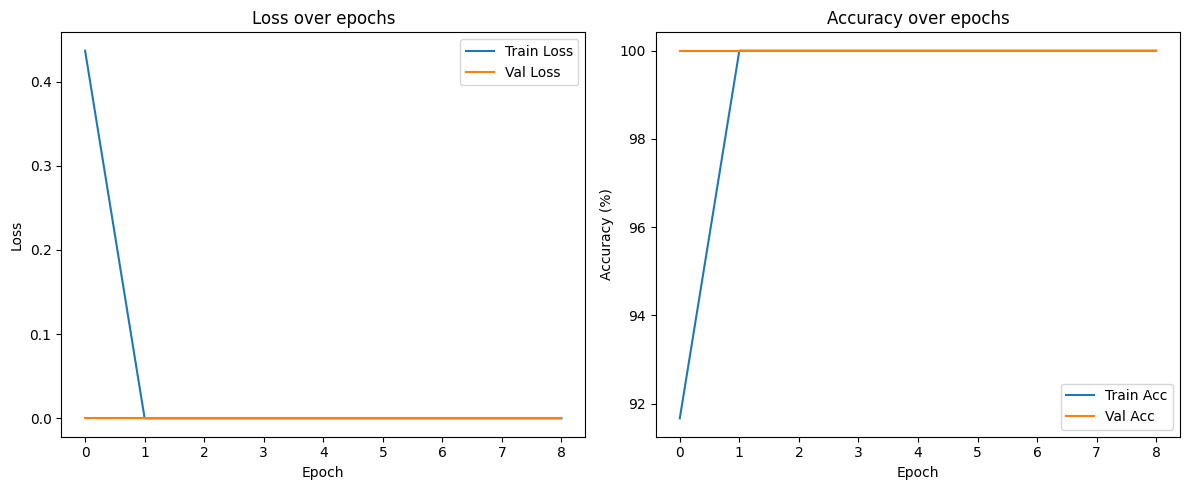

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import cv2
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Define constants
NUM_CLASSES = num_classes  # Use your existing variable
NUM_FRAMES = TARGET_FRAMES  # Use your existing variable
IMAGE_SIZE = 128  # Smaller size for faster processing
BATCH_SIZE = 8
EPOCHS = 10
LEARNING_RATE = 0.001

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define a simple CNN model for video classification
class SimpleVideoClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SimpleVideoClassifier, self).__init__()
        
        # 3D CNN for processing video frames
        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            
            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            
            nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            
            nn.Conv3d(256, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2)),
        )
        
        # Calculate output size after conv layers
        self.feature_size = 256 * (NUM_FRAMES//2) * (IMAGE_SIZE//16) * (IMAGE_SIZE//16)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_size, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # Input shape: [batch_size, channels, frames, height, width]
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

class FlexibleVideoDataset(Dataset):
    def __init__(self, data_source, num_frames=16, image_size=128, transform=None):
        """
        A flexible dataset class that can handle various input formats
        
        Args:
            data_source: Could be a generator, list, or array
            num_frames: Number of frames to use per video
            image_size: Size to resize frames to
            transform: Optional transforms to apply
        """
        self.data_source = data_source
        self.num_frames = num_frames
        self.image_size = image_size
        self.transform = transform
        
        # Try to determine length
        try:
            self.length = len(data_source)
            print(f"Dataset length: {self.length}")
        except:
            print("Warning: Could not determine dataset length")
            self.length = 100  # Fallback value
    
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        try:
            # Get the raw item first
            item = self.data_source[idx]
            
            # Extract frames and label based on item type
            frames = None
            label = 0
            
            # Case 1: Item is a tuple/list (common format: (frames/path, label))
            if isinstance(item, (tuple, list)) and len(item) >= 2:
                potential_frames = item[0]
                potential_label = item[1]
                
                # Handle the label first (simpler)
                if isinstance(potential_label, np.ndarray):
                    # Convert numpy array to scalar
                    if potential_label.size == 1:
                        label = int(potential_label.item())
                    else:
                        label = int(potential_label.flat[0])  # Get first element safely
                elif isinstance(potential_label, (int, float)):
                    label = int(potential_label)
                else:
                    # Try to convert to int
                    try:
                        label = int(float(str(potential_label).strip()))
                    except:
                        label = 0  # Default if conversion fails
                
                # Now handle the frames
                if isinstance(potential_frames, np.ndarray):
                    # If it's a numpy array, figure out its structure
                    if potential_frames.ndim == 4:  # [frames, height, width, channels]
                        frames = potential_frames
                    elif potential_frames.ndim == 3:  # Single frame [height, width, channels]
                        frames = np.array([potential_frames] * self.num_frames)
                    else:
                        # Create dummy frames as fallback
                        frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
                elif isinstance(potential_frames, str):
                    # It might be a path to video or frames
                    if os.path.isdir(potential_frames):
                        # Directory of frames
                        frame_files = sorted([os.path.join(potential_frames, f) for f in os.listdir(potential_frames) 
                                             if f.endswith(('.jpg', '.jpeg', '.png'))])[:self.num_frames]
                        frames = []
                        for f in frame_files:
                            img = cv2.imread(f)
                            if img is not None:
                                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                                img = cv2.resize(img, (self.image_size, self.image_size))
                                frames.append(img)
                        
                        if not frames:  # If no frames were loaded
                            frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
                        else:
                            frames = np.array(frames)
                    elif os.path.isfile(potential_frames) and potential_frames.endswith(('.mp4', '.avi', '.mov')):
                        # Video file
                        frames = self._extract_frames_from_video(potential_frames)
                    else:
                        # Unrecognized string, create dummy frames
                        frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
                else:
                    # Unrecognized frame format, create dummy frames
                    frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
            
            # Case 2: Item is a numpy array (could be just frames)
            elif isinstance(item, np.ndarray):
                # Try to interpret the array
                if item.ndim == 4:  # [frames, height, width, channels]
                    frames = item
                    label = 0  # Default label
                elif item.ndim > 4:  # More complex structure
                    # Try to find frames in the array
                    # This is a simplification - real code would need to be adapted to your data
                    frames = item.reshape(-1, self.image_size, self.image_size, 3)[:self.num_frames]
                    label = 0  # Default label
                else:
                    # Can't determine frames, create dummy data
                    frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
                    label = 0
            
            # Case 3: Other formats - create dummy data
            else:
                frames = np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
                label = 0
            
            # Ensure we have the right number of frames
            if frames.shape[0] > self.num_frames:
                frames = frames[:self.num_frames]
            elif frames.shape[0] < self.num_frames:
                # Pad with repeated frames
                pad_frames = np.repeat(frames[-1:], self.num_frames - frames.shape[0], axis=0)
                frames = np.concatenate([frames, pad_frames], axis=0)
            
            # Ensure frames are the right size
            resized_frames = []
            for frame in frames:
                if frame.shape[0] != self.image_size or frame.shape[1] != self.image_size:
                    frame = cv2.resize(frame, (self.image_size, self.image_size))
                resized_frames.append(frame)
            frames = np.array(resized_frames)
            
            # Convert to tensor format [channels, frames, height, width]
            frames = frames.astype(np.float32) / 255.0  # Normalize to [0,1]
            frames = np.transpose(frames, (3, 0, 1, 2))  # THWC -> CTHW
            frames_tensor = torch.from_numpy(frames)
            label_tensor = torch.tensor(label, dtype=torch.long)
            
            return frames_tensor, label_tensor
        
        except Exception as e:
            print(f"Error processing item {idx}: {str(e)}")
            # Return dummy data in case of errors
            dummy_frames = torch.zeros(3, self.num_frames, self.image_size, self.image_size, dtype=torch.float32)
            dummy_label = torch.tensor(0, dtype=torch.long)
            return dummy_frames, dummy_label
    
    def _extract_frames_from_video(self, video_path):
        """Extract frames from a video file"""
        try:
            cap = cv2.VideoCapture(video_path)
            frames = []
            frame_count = 0
            
            while frame_count < self.num_frames:
                ret, frame = cap.read()
                if not ret:
                    break
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.image_size, self.image_size))
                frames.append(frame)
                frame_count += 1
            
            cap.release()
            
            if not frames:
                return np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)
            
            frames = np.array(frames)
            
            # If we didn't get enough frames, pad with the last frame
            if frames.shape[0] < self.num_frames:
                last_frame = frames[-1]
                padding = np.array([last_frame] * (self.num_frames - frames.shape[0]))
                frames = np.concatenate([frames, padding])
            
            return frames
        
        except Exception as e:
            print(f"Error extracting frames from video {video_path}: {str(e)}")
            return np.zeros((self.num_frames, self.image_size, self.image_size, 3), dtype=np.uint8)

# Create datasets and data loaders
train_dataset = FlexibleVideoDataset(train_gen, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE)
val_dataset = FlexibleVideoDataset(val_gen, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE)

# Test access to first item
print("\nTesting access to first dataset item...")
try:
    frames, label = train_dataset[0]
    print(f"Success! Loaded frames tensor of shape {frames.shape} and label {label}")
except Exception as e:
    print(f"Error accessing first item: {str(e)}")
    import traceback
    traceback.print_exc()

# Create data loaders with error handling
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,  # For debugging
    drop_last=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,  # For debugging
    drop_last=False
)

# Test batch loading
print("\nTesting batch loading from data loader...")
try:
    for i, (frames, labels) in enumerate(train_loader):
        print(f"Successfully loaded batch {i}: frames shape {frames.shape}, labels shape {labels.shape}")
        if i >= 2:
            break
except Exception as e:
    print(f"Error loading batch: {str(e)}")
    import traceback
    traceback.print_exc()

# Initialize the model, loss function, and optimizer
model = SimpleVideoClassifier(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Define training and validation functions
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    for frames, labels in progress_bar:
        # Move data to device
        frames, labels = frames.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': running_loss / (progress_bar.n + 1),
            'acc': 100 * correct / total
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Validation")
        for frames, labels in progress_bar:
            # Move data to device
            frames, labels = frames.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            # Track statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            progress_bar.set_postfix({
                'val_loss': running_loss / (progress_bar.n + 1)
            })
    
    # Calculate metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds) * 100
    
    return epoch_loss, epoch_acc

# Training loop
print("\nStarting training...")
train_losses = []
train_accs = []
val_losses = []
val_accs = []

try:
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        print(f"Training: Loss = {train_loss:.4f}, Accuracy = {train_acc:.2f}%")
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"Validation: Loss = {val_loss:.4f}, Accuracy = {val_acc:.2f}%")
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        }, f'video_classifier_checkpoint_epoch_{epoch+1}.pth')
        
        # Early stopping could be added here
except Exception as e:
    print(f"Error during training: {str(e)}")
    import traceback
    traceback.print_exc()

# Plot training results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()

print("Training complete!")

In [ ]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import deque
import os
from IPython.display import clear_output, display

# Define constants (same as in training)
NUM_CLASSES = num_classes  # Use your existing variable
NUM_FRAMES = TARGET_FRAMES  # Use your existing variable
IMAGE_SIZE = 128  # Same as training
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names - replace with your actual class names
class_names = [f"Class {i}" for i in range(NUM_CLASSES)]
# If you have actual class names, use them instead:
# class_names = ["Walking", "Running", "Jumping", "Sitting", ...]

# Re-define the model architecture (same as in training)

# Function to load the trained model
def load_model(model_path):
    try:
        checkpoint = torch.load(model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Model loaded successfully from {model_path}")
        print(f"Checkpoint from epoch {checkpoint['epoch']} with validation accuracy {checkpoint['val_acc']:.2f}%")
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        print("Initializing model with random weights instead")
    
    model.eval()
    return model

# Function to preprocess a video file for testing
def process_video_file(video_path, model):
    try:
        # Open the video file
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file {video_path}")
            return
        
        # Get video properties
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = frame_count / fps
        
        print(f"Video: {video_path}")
        print(f"FPS: {fps}, Total Frames: {frame_count}, Duration: {duration:.2f}s")
        
        # Sample frames evenly throughout the video
        frames = []
        frame_indices = np.linspace(0, frame_count-1, NUM_FRAMES, dtype=int)
        
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
                frames.append(frame)
            else:
                print(f"Error reading frame at index {idx}")
        
        cap.release()
        
        if len(frames) < NUM_FRAMES:
            # If we couldn't get enough frames, pad with the last frame
            if frames:
                while len(frames) < NUM_FRAMES:
                    frames.append(frames[-1])
            else:
                # If no frames were read, create blank frames
                blank = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
                frames = [blank] * NUM_FRAMES
        
        # Convert to tensor
        frames_array = np.array(frames, dtype=np.float32) / 255.0
        frames_tensor = torch.from_numpy(np.transpose(frames_array, (3, 0, 1, 2))).unsqueeze(0).to(DEVICE)
        
        # Run inference
        with torch.no_grad():
            outputs = model(frames_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()[0]
            
            predicted_class = np.argmax(probs)
            confidence = probs[predicted_class]
        
        # Display results
        print(f"\nPrediction: {class_names[predicted_class]} with {confidence*100:.2f}% confidence")
        
        # Display top 3 predictions
        top_k = 3
        top_indices = np.argsort(probs)[-top_k:][::-1]
        print("\nTop predictions:")
        for idx in top_indices:
            print(f"{class_names[idx]}: {probs[idx]*100:.2f}%")
        
        # Display sample frames
        plt.figure(figsize=(15, 8))
        for i, idx in enumerate(np.linspace(0, len(frames)-1, 5, dtype=int)):
            plt.subplot(1, 5, i+1)
            plt.imshow(frames[idx])
            plt.title(f"Frame {idx}")
            plt.axis('off')
        plt.suptitle(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}%)")
        plt.tight_layout()
        plt.show()
        
        return predicted_class, probs
        
    except Exception as e:
        print(f"Error processing video file: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

# Function to run a live camera test
def run_live_camera_test(model, duration=20, fps=15):
    """
    Run a live camera test for the specified duration.
    
    Args:
        model: The model to use for predictions
        duration: Duration of the test in seconds
        fps: Frames per second to capture
    """
    print("Starting live camera test...")
    try:
        # Open the camera
        cap = cv2.VideoCapture(0)  # 0 for default camera
        if not cap.isOpened():
            print("Error: Could not open camera")
            return
        
        # Set camera properties
        cam_width = 640
        cam_height = 480
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, cam_width)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, cam_height)
        
        # Create a deque to store frames
        frame_deque = deque(maxlen=NUM_FRAMES)
        
        # Initialize with empty frames
        empty_frame = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        for _ in range(NUM_FRAMES):
            frame_deque.append(empty_frame)
        
        # Variables for FPS calculation
        frame_times = deque(maxlen=30)
        last_time = time.time()
        
        # Variables for prediction throttling
        last_prediction_time = time.time()
        prediction_interval = 1.0  # Make a prediction every 1 second
        
        # Create a window for display
        cv2.namedWindow('Live Prediction', cv2.WINDOW_NORMAL)
        cv2.resizeWindow('Live Prediction', cam_width, cam_height)
        
        # Current predictions
        current_pred_class = None
        current_probs = None
        
        print("Camera opened successfully. Press 'q' to quit.")
        
        # Main loop
        start_time = time.time()
        while time.time() - start_time < duration:
            # Capture frame
            ret, frame = cap.read()
            if not ret:
                print("Error: Failed to capture frame")
                break
            
            # Calculate FPS
            current_time = time.time()
            frame_times.append(current_time - last_time)
            last_time = current_time
            current_fps = len(frame_times) / sum(frame_times)
            
            # Preprocess frame
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, (IMAGE_SIZE, IMAGE_SIZE))
            
            # Add to deque
            frame_deque.append(frame_resized)
            
            # Make prediction (throttled)
            if current_time - last_prediction_time >= prediction_interval:
                # Convert frames to tensor
                frames_array = np.array(list(frame_deque), dtype=np.float32) / 255.0
                frames_tensor = torch.from_numpy(np.transpose(frames_array, (3, 0, 1, 2))).unsqueeze(0).to(DEVICE)
                
                # Run inference
                with torch.no_grad():
                    outputs = model(frames_tensor)
                    probs = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()[0]
                    
                    predicted_class = np.argmax(probs)
                    confidence = probs[predicted_class]
                
                current_pred_class = predicted_class
                current_probs = probs
                last_prediction_time = current_time
            
            # Display frame with prediction
            display_frame = frame.copy()
            
            # Add prediction text
            if current_pred_class is not None:
                # Display class name and confidence
                text = f"{class_names[current_pred_class]}: {current_probs[current_pred_class]*100:.1f}%"
                cv2.putText(display_frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                # Display top 3 predictions
                top_indices = np.argsort(current_probs)[-3:][::-1]  # Get indices of top 3 classes
                for i, idx in enumerate(top_indices):
                    if i == 0:  # Skip the first one (already displayed)
                        continue
                    text = f"{class_names[idx]}: {current_probs[idx]*100:.1f}%"
                    cv2.putText(display_frame, text, (10, 30 + 30*i), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            # Display FPS
            cv2.putText(display_frame, f"FPS: {current_fps:.1f}", (10, cam_height - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            # Display the frame
            cv2.imshow('Live Prediction', display_frame)
            
            # Exit on 'q' press
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Exiting on user request")
                break
                
            # Control frame rate
            time.sleep(max(0, 1/fps - (time.time() - current_time)))
        
        # Clean up
        cap.release()
        cv2.destroyAllWindows()
        
    except Exception as e:
        print(f"Error in live camera test: {str(e)}")
        import traceback
        traceback.print_exc()

# Function to run batch testing on a folder of videos
def batch_test_videos(model, video_folder):
    """
    Test the model on all videos in a folder.
    
    Args:
        model: The trained model
        video_folder: Path to folder containing video files
    """
    print(f"Batch testing videos in folder: {video_folder}")
    
    # Check if folder exists
    if not os.path.isdir(video_folder):
        print(f"Error: Folder {video_folder} does not exist")
        return
    
    # Get all video files
    video_extensions = ['.mp4', '.avi', '.mov', '.mkv']
    video_files = []
    
    for ext in video_extensions:
        video_files.extend([os.path.join(video_folder, f) for f in os.listdir(video_folder) if f.endswith(ext)])
    
    if not video_files:
        print(f"No video files found in {video_folder}")
        return
    
    print(f"Found {len(video_files)} video files")
    
    # Process each video
    results = []
    for i, video_path in enumerate(video_files):
        print(f"\nProcessing video {i+1}/{len(video_files)}: {os.path.basename(video_path)}")
        predicted_class, probs = process_video_file(video_path, model)
        
        if predicted_class is not None:
            results.append({
                'video': os.path.basename(video_path),
                'predicted_class': predicted_class,
                'predicted_label': class_names[predicted_class],
                'confidence': probs[predicted_class]
            })
    
    # Print summary
    print("\n===== Summary =====")
    print(f"Processed {len(results)} videos")
    
    # Count predictions by class
    class_counts = {}
    for result in results:
        label = result['predicted_label']
        class_counts[label] = class_counts.get(label, 0) + 1
    
    print("\nPredictions by class:")
    for label, count in class_counts.items():
        print(f"{label}: {count} videos ({count/len(results)*100:.1f}%)")
    
    # Plot distribution
    plt.figure(figsize=(10, 6))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title('Prediction Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return results

# Main function to run tests
def main():
    # Ask for the checkpoint file path
    model_path = input("/kaggle/working/video_classifier_checkpoint_epoch_9.pth")
    if not model_path.strip():
        model_path = None
    
    # Load the model
    model = load_model(model_path) if model_path else SimpleVideoClassifier(NUM_CLASSES).to(DEVICE)
    model.eval()
    
    # Menu
    while True:
        print("\n===== Video Classification Testing =====")
        print("1. Test with a video file")
        print("2. Test with live camera")
        print("3. Batch test videos in a folder")
        print("4. Exit")
        
        choice = input("\nEnter your choice (1-4): ")
        
        if choice == '1':
            video_path = input("Enter path to video file: ")
            if os.path.isfile(video_path):
                process_video_file(video_path, model)
            else:
                print(f"Error: File {video_path} does not exist")
        
        elif choice == '2':
            try:
                duration = int(input("Enter test duration in seconds (default: 20): ") or 20)
                run_live_camera_test(model, duration=duration)
            except ValueError:
                print("Invalid duration. Using default value of 20 seconds.")
                run_live_camera_test(model)
        
        elif choice == '3':
            folder_path = input("Enter path to folder containing videos: ")
            batch_test_videos(model, folder_path)
        
        elif choice == '4':
            print("Exiting...")
            break
        
        else:
            print("Invalid choice. Please enter a number between 1 and 4.")

# If running directly, execute main function
if __name__ == "__main__":
    main()